# Stage 1: Data Structures
This notebook generates CUSUM events and dollar bars.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import sys
import os

sys.path.append('../')
from src.data_structures import cusum_filter, get_dollar_bars, calibrate_cusum_h, calibrate_dollar_bar_threshold

plt.style.use('seaborn-v0_8-darkgrid')


## 1. Load Cleaned Data


In [12]:
df = pd.read_parquet('../data/processed/nvda_clean.parquet')
df.head()


,Adj Close,Close,High,Low,Open,Volume,log_return,dollar_volume
Date,,,,,,,,
2005-01-04,0.171668,0.187250,0.198250,0.184250,0.197917,790224000,-0.048218,1.356562e+08
2005-01-05,0.173272,0.189000,0.191250,0.184250,0.185250,724812000,0.009302,1.255898e+08
2005-01-06,0.171592,0.187167,0.194583,0.185833,0.192333,563568000,-0.009745,9.670370e+07
2005-01-07,0.168306,0.183583,0.189000,0.180833,0.187583,763092000,-0.019335,1.284330e+08
2005-01-10,0.168688,0.184000,0.185833,0.182917,0.184167,579552000,0.002269,9.776370e+07


## 2. CUSUM Filter Calibration and Application


In [13]:
target_events = 400
best_h = calibrate_cusum_h(df['Adj Close'], target_events=target_events)
print(f"Calibrated h: {best_h}")

cusum_events = cusum_filter(df['Adj Close'], best_h)
print(f"Number of CUSUM events: {len(cusum_events)}")


Calibrated h: 0.02709502716064453
Number of CUSUM events: 400


## 3. Dollar Bars Calibration and Generation


In [14]:
target_bars_per_year = 252
threshold = calibrate_dollar_bar_threshold(df, target_bars_per_year=target_bars_per_year)
print(f"Calibrated Dollar Bar Threshold: {threshold}")

dollar_bars = get_dollar_bars(df, threshold)
print(f"Number of dollar bars generated: {len(dollar_bars)}")
dollar_bars.head()


Calibrated Dollar Bar Threshold: 4849548711.180383
Number of dollar bars generated: 1628


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2005-02-22,0.197917,0.244083,0.170500,0.238583,0.218729,2.682943e+10
2005-04-21,0.234750,0.246667,0.175833,0.187083,0.171515,2.553544e+10
2005-06-14,0.185917,0.244917,0.174333,0.224250,0.205589,2.571762e+10
2005-08-08,0.222833,0.244167,0.211833,0.236250,0.216590,2.387550e+10
2005-09-26,0.236583,0.282917,0.229750,0.274833,0.251963,2.060675e+10


## 4. Comparison: Bar Count Per Year


In [15]:
daily_bars_per_year = len(df) / ((df.index.max() - df.index.min()).days / 365.25)
dollar_bars_per_year = len(dollar_bars) / ((dollar_bars.index.max() - dollar_bars.index.min()).days / 365.25)

print(f"Daily bars per year (avg): {daily_bars_per_year:.2f}")
print(f"Dollar bars per year (avg): {dollar_bars_per_year:.2f}")


Daily bars per year (avg): 251.65
Dollar bars per year (avg): 80.66


## 5. Plots


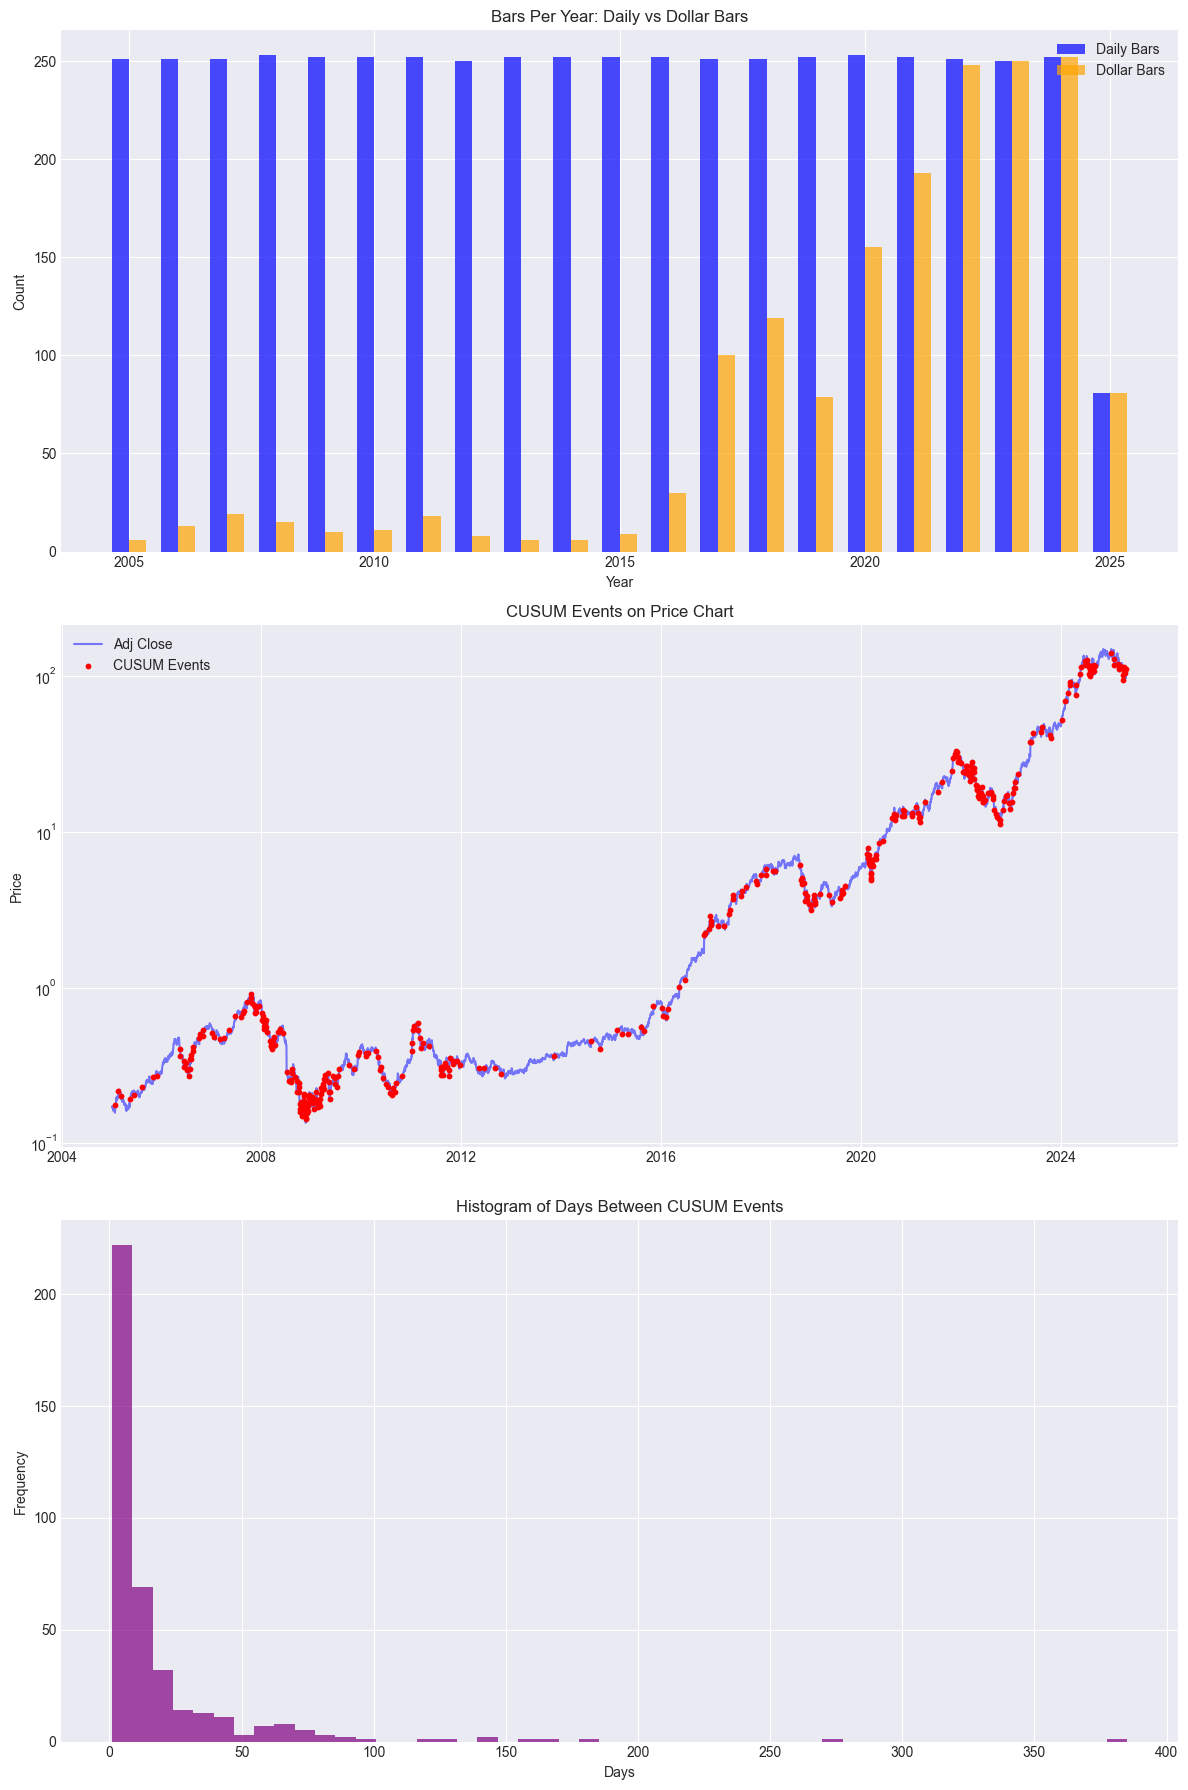

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# a. Bar count per year comparison
years = df.index.year.unique()
daily_counts = df.groupby(df.index.year).size()
dollar_counts = dollar_bars.groupby(dollar_bars.index.year).size()

width = 0.35
axes[0].bar(years - width/2, daily_counts, width, label='Daily Bars', color='blue', alpha=0.7)
axes[0].bar(years + width/2, dollar_counts, width, label='Dollar Bars', color='orange', alpha=0.7)
axes[0].set_title('Bars Per Year: Daily vs Dollar Bars')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].legend()

# b. CUSUM events on price chart
axes[1].plot(df.index, df['Adj Close'], label='Adj Close', color='blue', alpha=0.5)
axes[1].scatter(cusum_events, df.loc[cusum_events, 'Adj Close'], color='red', label='CUSUM Events', zorder=5, s=10)
axes[1].set_title('CUSUM Events on Price Chart')
axes[1].set_ylabel('Price')
axes[1].set_yscale('log')
axes[1].legend()

# c. Histogram of days between CUSUM events
inter_event_days = pd.Series(cusum_events).diff().dt.days.dropna()
axes[2].hist(inter_event_days, bins=50, color='purple', alpha=0.7)
axes[2].set_title('Histogram of Days Between CUSUM Events')
axes[2].set_xlabel('Days')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## 6. Normality Test: Daily vs Dollar Bar Returns


In [17]:
daily_returns = np.log(df['Adj Close'] / df['Adj Close'].shift(1)).dropna()
dollar_returns = np.log(dollar_bars['Close'] / dollar_bars['Close'].shift(1)).dropna()

jb_stat_daily, jb_p_daily = stats.jarque_bera(daily_returns)
jb_stat_dollar, jb_p_dollar = stats.jarque_bera(dollar_returns)

print(f"Daily Returns Jarque-Bera: stat={jb_stat_daily:.2f}, p={jb_p_daily:.4f}")
print(f"Dollar Bar Returns Jarque-Bera: stat={jb_stat_dollar:.2f}, p={jb_p_dollar:.4f}")


Daily Returns Jarque-Bera: stat=16417.43, p=0.0000
Dollar Bar Returns Jarque-Bera: stat=14322.35, p=0.0000


## 7. Save Outputs


In [18]:
pd.DataFrame(index=cusum_events).to_parquet('../data/processed/nvda_cusum_events.parquet')
dollar_bars.to_parquet('../data/processed/nvda_dollar_bars.parquet')
print("Saved nvda_cusum_events.parquet and nvda_dollar_bars.parquet to data/processed/")


Saved nvda_cusum_events.parquet and nvda_dollar_bars.parquet to data/processed/
